# Transformers for Sequence Data

Specialized neural network modules for processing data sequences.

<span class="column-margin margin-aside">Much of the code for this lecture is based on [this tutorial](https://www.datacamp.com/tutorial/building-a-transformer-with-py-torch) by Arjun Sarkar for DataCamp.</span>

In [ ]:
import torch 
from torch.utils.data import Dataset, DataLoader
from tokenizers import Tokenizer
from tokenizers.models import BPE
from tokenizers.trainers import BpeTrainer
from torch import nn
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

## Sequence Data

## The Attention Mechanism

The use of the attention mechanism for natural language processing took off with with a seminal paper by Vaswani et al. (2017), which integrated the attention mechanism into a neural network architecture called the *transformer*.

The attention mechanism is a technical expression of a simple idea:

<figure id="fig-attention-diagrams">
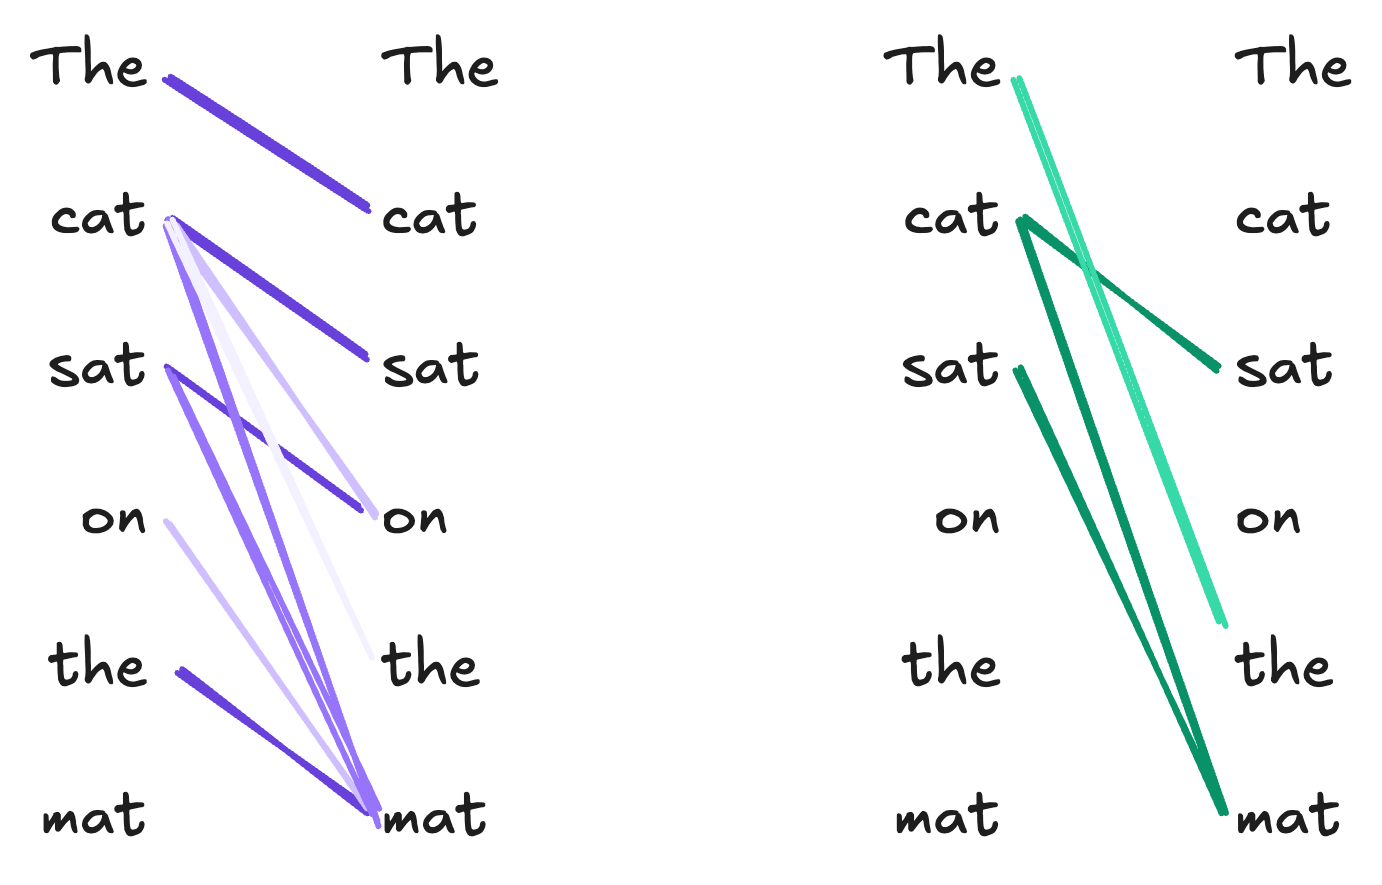
<figcaption>Figure 1: Schematic diagrams of two attention heads performing different functions. The first attention on the left picks up referential relationships between words, while the one on the right has been trained to detect rhyming words.</figcaption>
</figure>

### Dr. Seuss Example

In [ ]:
import urllib
url = "https://raw.githubusercontent.com/middcs/data-science-notes/refs/heads/main/data/seuss/places.txt"
text = "\n".join([line.decode('utf-8').strip() for line in urllib.request.urlopen(url)])
print(text[0:193])

Dataset code from previous lecture notes.

In [ ]:
data = TextDataSet(
    text, 
    tokenizer = tokenizer, 
    trainer = trainer, 
    context_length = 5
    )
print(f"Number of training examples: {len(data)}")
print(f"Vocabulary size: {data.vocab_length}")

In [ ]:
class TextDataSet(Dataset):
    def __init__(self, text, tokenizer = Tokenizer(BPE()), trainer = BpeTrainer(min_frequency=10), context_length = 5): 
        self.context_length = context_length
        self.text = text
        self.tokenizer = tokenizer
        self.tokenizer.train_from_iterator([text], trainer)
        self.tokens = self.tokenizer.encode(text).ids
        self.vocab_length = self.tokenizer.get_vocab_size()

    def __len__(self):
        return len(self.tokens) - self.context_length
    
    def __getitem__(self, key):
        target = torch.tensor(self.tokens[self.context_length + key])
        features = self.tokens[key:(self.context_length + key)]

        feature_tensor = torch.tensor(features, dtype=torch.long)
        feature_text = self.tokenizer.decode(features)
        target_text = self.tokenizer.decode([target])

        return feature_tensor.to(device), target.to(device), feature_text, target_text

### Key-Query-Value (KQV) Attention

<span class="column-margin margin-aside">The mathematical exposition of the KQV attention mechanism is based on Chapter 12.1 of Bishop and Bishop (2023).</span>

In [ ]:
class AttentionHead(torch.nn.Module):
    def __init__(self, d_model, d_k):
        super().__init__()
        self.W_q = torch.nn.Linear(d_model, d_k)
        self.W_k = torch.nn.Linear(d_model, d_k)
        self.W_v = torch.nn.Linear(d_model, d_k)

    def forward(self, x):
        Q = self.W_q(x)  # Queries
        K = self.W_k(x)  # Keys
        V = self.W_v(x)  # Values

        # Compute attention scores
        scores = torch.matmul(Q, K.transpose(-2, -1)) / (K.size(-1) ** 0.5)
        attention_weights = torch.nn.functional.softmax(scores, dim=-1)

        # Compute the output as a weighted sum of values
        output = torch.matmul(attention_weights, V)
        return output

In [ ]:
class PositionalEncoding(torch.nn.Module):
    def __init__(self, d_model, max_len=5000):
        super().__init__()
        pe = torch.zeros(max_len, d_model)
        position = torch.arange(0, max_len).unsqueeze(1)
        div_term = torch.exp(torch.arange(0, d_model, 2) * -(torch.log(torch.tensor(10000.0)) / d_model))
        pe[:, 0::2] = torch.sin(position * div_term)
        pe[:, 1::2] = torch.cos(position * div_term)
        self.register_buffer('pe', pe)

    def forward(self, x):
        x = x + self.pe[:x.size(1), :]
        return x

In [ ]:
class MultiHeadAttention(torch.nn.Module):
    def __init__(self, d_model, d_k, num_heads):
        super().__init__()
        self.heads = torch.nn.ModuleList([AttentionHead(d_model, d_k) for _ in range(num_heads)])
        self.linear = torch.nn.Linear(num_heads * d_k, d_model)

    def forward(self, x):
        head_outputs = [head(x) for head in self.heads]
        concatenated = torch.cat(head_outputs, dim=-1)
        output = self.linear(concatenated)
        return output

### Self-Attention

## A First Attention-Based Model

## Towards Transformers

## References

Bishop, Christopher M, and Hugh Bishop. 2023. *Deep Learning: Foundations and Concepts*. Springer Nature.

Vaswani, Ashish, Noam Shazeer, Niki Parmar, Jakob Uszkoreit, Llion Jones, Aidan N Gomez, Łukasz Kaiser, and Illia Polosukhin. 2017. “Attention Is All You Need.” *Advances In Neural Information Processing Systems* 30.